In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
from copy import deepcopy
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [2]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]

runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [3]:
def parse_grl_csv(file_path):
    grl_df = pd.read_csv(file_path)
    return grl_df

grl_2022_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2022_physics.csv")
grl_2023_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2023_physics.csv")
grl_2024_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2024_physics.csv")
grl_df = pd.concat([grl_2022_df, grl_2023_df, grl_2024_df], ignore_index=True)

In [4]:
def get_files_for_runs(run_range, data_files):
    selected_files = []
    for file in data_files:
        # Extract the run number from the filename
        run_number = int(os.path.basename(file).split('.')[0])
        if run_range[0] <= run_number <= run_range[1]:
            selected_files.append(file)
    return selected_files

In [51]:
data_files = glob.glob("AnalysisZipFramework/submission/analysis_output-moreHists3/*.root")

files_F222 = get_files_for_runs(runs_F222, data_files)
files_F223 = get_files_for_runs(runs_F223, data_files)
files_F231 = get_files_for_runs(runs_F231, data_files)
files_F232 = get_files_for_runs(runs_F232, data_files)
files_F241 = get_files_for_runs(runs_F241, data_files)
files_tungsten = get_files_for_runs(runs_tungsten, data_files)
files_F242 = get_files_for_runs(runs_F242, data_files)
files_caloNu = get_files_for_runs(runs_caloNu, data_files)
files_F243 = get_files_for_runs(runs_F243, data_files)


In [52]:
def check_files(files):

    new_files = []
    for file in tqdm(files):
        try:
            data = uproot.open(f"{file}:nt")
            new_files.append(file)
        except Exception as e:
            print(f"Error opening file {file}: {e}")
            continue
    return new_files

In [53]:
files_F222 = check_files(files_F222)
files_F223 = check_files(files_F223)
files_F231 = check_files(files_F231)
files_F232 = check_files(files_F232)
files_F241 = check_files(files_F241)
files_tungsten = check_files(files_tungsten)
files_F242 = check_files(files_F242)
files_caloNu = check_files(files_caloNu)
files_F243 = check_files(files_F243)

100%|██████████| 23/23 [00:09<00:00,  2.38it/s]


In [54]:
print(f"Files for F222: {len(files_F222)}")
print(f"Files for F223: {len(files_F223)}")
print(f"Files for F231: {len(files_F231)}")
print(f"Files for F232: {len(files_F232)}")
print(f"Files for F241: {len(files_F241)}")
print(f"Files for tungsten: {len(files_tungsten)}")
print(f"Files for F242: {len(files_F242)}")
print(f"Files for caloNu: {len(files_caloNu)}")
print(f"Files for F243: {len(files_F243)}")

Files for F222: 95
Files for F223: 83
Files for F231: 61
Files for F232: 28
Files for F241: 49
Files for tungsten: 43
Files for F242: 31
Files for caloNu: 130
Files for F243: 23


In [55]:
colours = ["lightcoral", "firebrick", "olive", "olivedrab", "teal", "lightblue", "steelblue", "magenta", "purple"]

hists_dict = {
    "F222": {"files": files_F222, "runs": runs_F222, "colour": colours[0]},
    "F223": {"files": files_F223, "runs": runs_F223, "colour": colours[1]},
    "F231": {"files": files_F231, "runs": runs_F231, "colour": colours[2]},
    "F232": {"files": files_F232, "runs": runs_F232, "colour": colours[3]},
    "F241": {"files": files_F241, "runs": runs_F241, "colour": colours[4]},
    "tungsten": {"files": files_tungsten, "runs": runs_tungsten, "colour": colours[5]},
    "F242": {"files": files_F242, "runs": runs_F242, "colour": colours[6]},
    "caloNu": {"files": files_caloNu, "runs": runs_caloNu, "colour": colours[7]},
    "F243": {"files": files_F243, "runs": runs_F243, "colour": colours[8]},
}

In [73]:
for period, info in tqdm(hists_dict.items()):

    data = uproot.concatenate([f"{f}:nt" for f in info["files"]], library="ak", filter_name=["LeadTrack_pz0", "LeadTrack_qop"])

    pz = data["LeadTrack_pz0"]
    qop = data["LeadTrack_qop"]

    bins = [100, 300, 600, 1000]
    h_pz = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())

    bins = [-1/100e3, -1/300e3, -1/600e3, -1/1000e3, 1/1000e3, 1/600e3, 1/300e3, 1/100e3]
    h_qop = bh.Histogram(bh.axis.Variable(bins), storage=bh.storage.Weight())

    h_pz.fill(pz)
    h_qop.fill(qop)

    hists_dict[period]["h_pz"] = h_pz
    hists_dict[period]["h_qop"] = h_qop
    

100%|██████████| 9/9 [01:31<00:00, 10.21s/it]


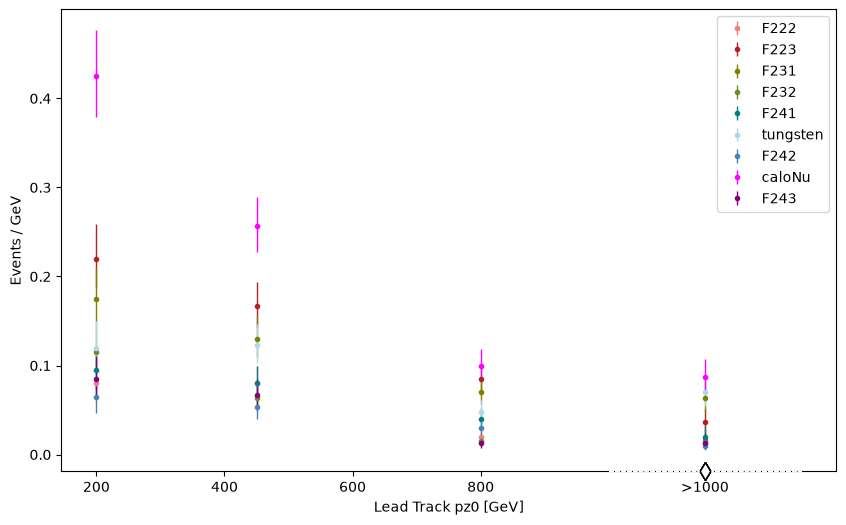

In [33]:
fig, ax = plt.subplots(figsize=(10, 6))

h_caloNu = deepcopy(hists_dict["caloNu"]["h_pz"])

for period, info in hists_dict.items():
    h_pz = deepcopy(info["h_pz"])

    mplhep.histplot(h_pz, ax=ax, label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', binwnorm=1)

ax.set_ylabel("Events / GeV")
ax.set_xlabel("Lead Track pz0 [GeV]")
ax.legend()

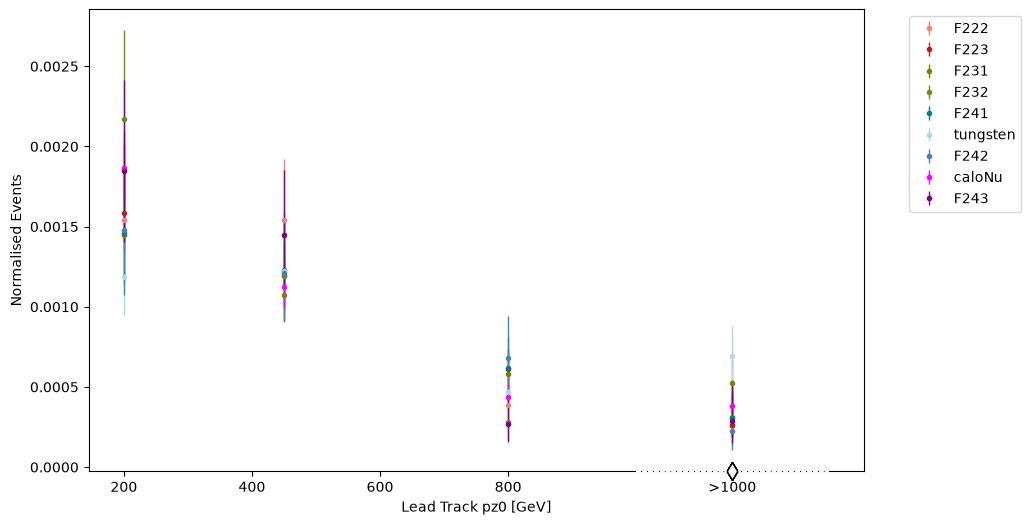

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

h_caloNu = deepcopy(hists_dict["caloNu"]["h_pz"])

for period, info in hists_dict.items():
    h_pz = deepcopy(info["h_pz"])

    mplhep.histplot(h_pz, ax=ax, label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=True)

ax.set_ylabel("Normalised Events")
ax.set_xlabel("Lead Track pz0 [GeV]")
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

TypeError: ufunc 'divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

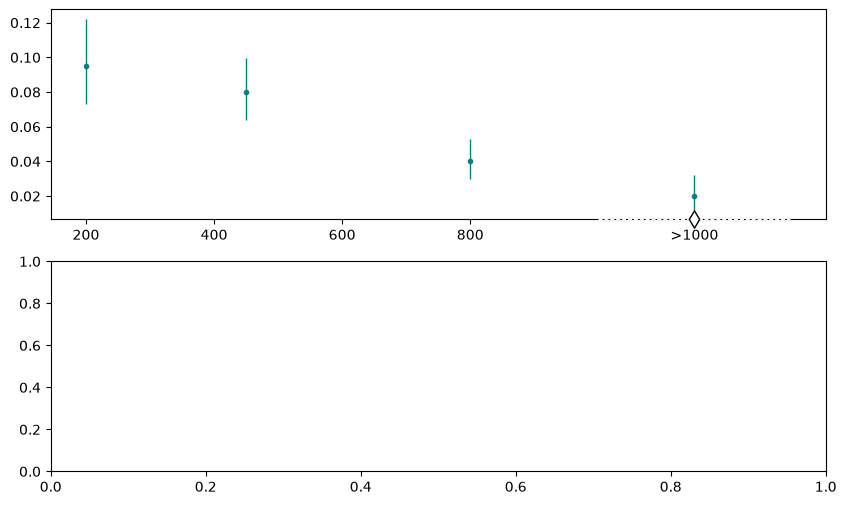

In [35]:
fig, ax = plt.subplots(figsize=(10, 6), nrows=2)

h_caloNu = deepcopy(hists_dict["caloNu"]["h_pz"])

for period, info in hists_dict.items():

    if period == "F222" or period == "F223" or period == "F231" or period == "F232":
        continue



    h_pz = deepcopy(info["h_pz"])

    mplhep.histplot(h_pz, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', binwnorm=1)


    if period != "caloNu":

        h_calonu_norm = deepcopy(h_caloNu) / h_caloNu.sum()
        h_pz_norm = deepcopy(h_pz) / h_pz.sum()

        h_ratio = h_pz_norm / h_calonu_norm

        mplhep.histplot(h_ratio, ax=ax[1], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show')

ax[1].axhline(1, color="black", linestyle="--", linewidth=1)

ax[0].set_ylabel("Events / GeV")
ax[0].set_xlabel("Lead Track pz0 [GeV]")
ax[0].legend()

In [ ]:
def ratio_with_errors(h_num, h_den, flow=True):
    """Ratio of two normalised histograms with propagated uncertainties,
    optionally including under/overflow bins."""
    num_vals = h_num.values(flow=flow)
    den_vals = h_den.values(flow=flow)

    num_sum = h_num.sum(flow=flow)
    den_sum = h_den.sum(flow=flow)

    num_norm = num_vals / num_sum
    den_norm = den_vals / den_sum

    try:
        num_var = h_num.variances(flow=flow)
        den_var = h_den.variances(flow=flow)
    except RuntimeError:
        num_var = num_vals
        den_var = den_vals

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(den_norm != 0, num_norm / den_norm, np.nan)
        rel_err = np.sqrt(
            np.where(num_vals != 0, num_var / num_vals**2, 0)
            + np.where(den_vals != 0, den_var / den_vals**2, 0)
        )
        ratio_err = ratio * rel_err

    return ratio, ratio_err


def bin_centers_with_flow(h, flow=True):
    """Bin centers including under/overflow, placed one bin-width outside
    the first/last edge."""
    edges = h.axes[0].edges
    centers = h.axes[0].centers

    if not flow:
        return centers

    underflow_width = edges[1] - edges[0]
    overflow_width = edges[-1] - edges[-2]

    underflow_center = edges[0] - underflow_width / 2
    overflow_center = edges[-1] + overflow_width / 2

    return np.concatenate([[underflow_center], centers, [overflow_center]])

Text(0, 0.5, 'Normalised Events')

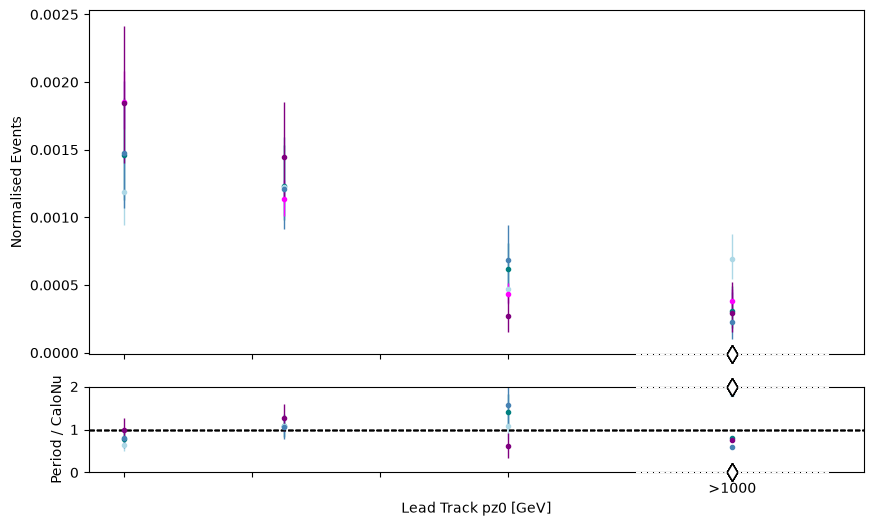

In [63]:
fig, ax = mplhep.subplots(nrows=2, ncols=1, figsize=(10, 6), sharex=True)

h_caloNu = deepcopy(hists_dict["caloNu"]["h_pz"])

for period, info in hists_dict.items():

    if period == "F222" or period == "F223" or period == "F231" or period == "F232":
        continue

    h_pz = deepcopy(info["h_pz"])

    density = True  # Set to True for normalised histograms, False for raw counts

    mplhep.histplot(h_pz, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=density)


    if period != "caloNu":

        n1 = (1.0 / h_pz.sum(flow=True).value)
        n2 = (1.0 / h_caloNu.sum(flow=True).value)

        h_pz_norm = h_pz * n1
        h_caloNu_norm = h_caloNu * n2

        mplhep.comp.comparison(h_pz_norm, h_caloNu_norm, ax=ax[1], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=False, comparison='ratio')

        # bin_centers = bin_centers_with_flow(h_caloNu, flow=True)

        # ratio, ratio_err = ratio_with_errors(h_pz, h_caloNu, flow=True)

        # ax[1].errorbar(bin_centers, ratio, yerr=ratio_err,
        #                 color=info["colour"], linewidth=2,
        #                 fmt='o', markersize=4)

ax[1].axhline(1, color="black", linestyle="--", linewidth=1)
ax[1].set_ylabel("Period / CaloNu")
ax[1].set_xlabel("Lead Track pz0 [GeV]")

ax[0].set_ylabel("Normalised Events")

Period: F241, h_qop sum: 65.0
Period: tungsten, h_qop sum: 101.0
Period: F242, h_qop sum: 44.0
Period: caloNu, h_qop sum: 229.0
Period: F243, h_qop sum: 46.0


<Axes: xlabel='Lead Track q/p [GeV]', ylabel='Period / CaloNu'>

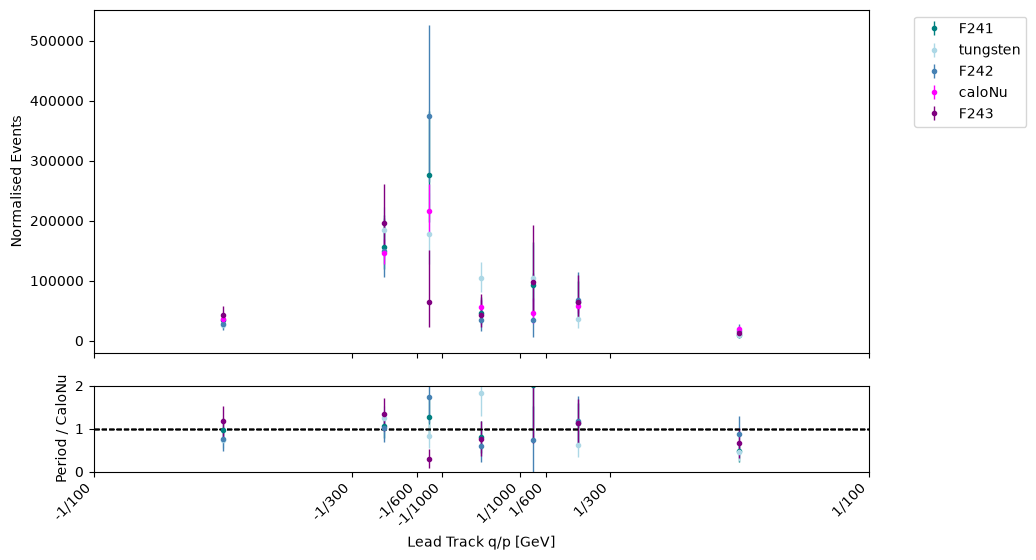

In [ ]:
fig, ax = mplhep.subplots(nrows=2, ncols=1, figsize=(10, 6))

h_caloNu = deepcopy(hists_dict["caloNu"]["h_qop"])

for period, info in hists_dict.items():

    if period == "F222" or period == "F223" or period == "F231" or period == "F232":
        continue

    h_qop = deepcopy(info["h_qop"])

    print(f"Period: {period}, h_qop sum: {h_qop.sum(flow=True).value}")

    density = True  # Set to True for normalised histograms, False for raw counts

    mplhep.histplot(h_qop, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=True)
    # mplhep.histplot(h_qop, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', binwnorm=1)


    if period != "caloNu":

        n1 = (1.0 / h_qop.sum(flow=True).value)
        n2 = (1.0 / h_caloNu.sum(flow=True).value)

        h_qop_norm = h_qop * n1
        h_caloNu_norm = h_caloNu * n2

        mplhep.comp.comparison(h_qop_norm, h_caloNu_norm, ax=ax[1], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=False, comparison='ratio')

        # bin_centers = bin_centers_with_flow(h_caloNu, flow=True)

        # ratio, ratio_err = ratio_with_errors(h_pz, h_caloNu, flow=True)

        # ax[1].errorbar(bin_centers, ratio, yerr=ratio_err,
        #                 color=info["colour"], linewidth=2,
        #                 fmt='o', markersize=4)

ax[1].axhline(1, color="black", linestyle="--", linewidth=1)
ax[1].set_ylabel("Period / CaloNu")
ax[1].set_xlabel("Lead Track q/p [GeV]")



tick_positions = [-1/100e3, -1/300e3, -1/600e3, -1/1000e3, 1/1000e3, 1/600e3, 1/300e3, 1/100e3]
# tick_positions = [-1, -2, -3, -4, 4, 3, 2, 1]  # Adjusted tick positions for better visibility
tick_labels = ["-1/100", "-1/300", "-1/600", "-1/1000", "1/1000", "1/600", "1/300", "1/100"]
tick_labels_dummy = ["" for _ in tick_labels]  # Create a list of empty strings for dummy labels

ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_labels)
ax[1].set_xticklabels(tick_labels, rotation=45, ha='right')

ax[0].set_xticks(tick_positions)
ax[0].set_xticklabels(tick_labels)
ax[0].set_xticklabels(tick_labels_dummy, rotation=45, ha='right')


ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].set_ylabel("Normalised Events")
mplhep.mpl_magic(soft_fail=True)


Period: F241, h_qop sum: 65.0
Period: tungsten, h_qop sum: 101.0
Period: F242, h_qop sum: 44.0
Period: caloNu, h_qop sum: 229.0
Period: F243, h_qop sum: 46.0


<Axes: xlabel='Lead Track q/p [GeV]', ylabel='Period / CaloNu'>

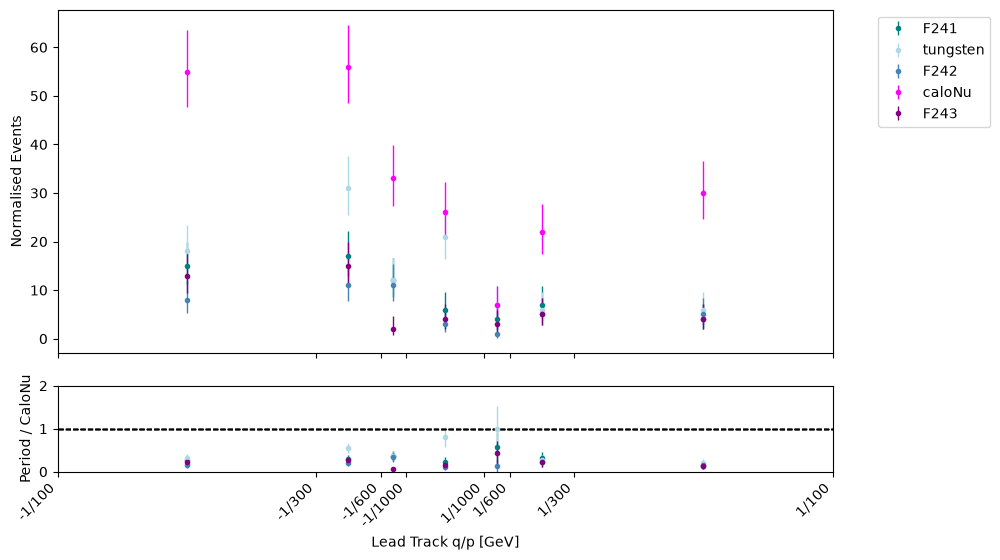

In [95]:
fig, ax = mplhep.subplots(nrows=2, ncols=1, figsize=(10, 6))

h_caloNu = deepcopy(hists_dict["caloNu"]["h_qop"])

for period, info in hists_dict.items():

    if period == "F222" or period == "F223" or period == "F231" or period == "F232":
        continue

    h_qop = deepcopy(info["h_qop"])

    print(f"Period: {period}, h_qop sum: {h_qop.sum(flow=True).value}")

    density = False  # Set to True for normalised histograms, False for raw counts

    mplhep.histplot(h_qop, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=density)
    # mplhep.histplot(h_qop, ax=ax[0], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', binwnorm=1)


    if period != "caloNu":

        # n1 = (1.0 / h_qop.sum(flow=True).value)
        # n2 = (1.0 / h_caloNu.sum(flow=True).value)

        # h_pz_norm = h_qop * n1
        # h_caloNu_norm = h_caloNu * n2

        mplhep.comp.comparison(h_qop, h_caloNu, ax=ax[1], label=period, color=info["colour"], histtype="errorbar", linewidth=2, flow='show', density=False, comparison='ratio')

        # bin_centers = bin_centers_with_flow(h_caloNu, flow=True)

        # ratio, ratio_err = ratio_with_errors(h_pz, h_caloNu, flow=True)

        # ax[1].errorbar(bin_centers, ratio, yerr=ratio_err,
        #                 color=info["colour"], linewidth=2,
        #                 fmt='o', markersize=4)

ax[1].axhline(1, color="black", linestyle="--", linewidth=1)
ax[1].set_ylabel("Period / CaloNu")
ax[1].set_xlabel("Lead Track q/p [GeV]")



tick_positions = [-1/100e3, -1/300e3, -1/600e3, -1/1000e3, 1/1000e3, 1/600e3, 1/300e3, 1/100e3]
# tick_positions = [-1, -2, -3, -4, 4, 3, 2, 1]  # Adjusted tick positions for better visibility
tick_labels = ["-1/100", "-1/300", "-1/600", "-1/1000", "1/1000", "1/600", "1/300", "1/100"]
tick_labels_dummy = ["" for _ in tick_labels]  # Create a list of empty strings for dummy labels

ax[1].set_xticks(tick_positions)
ax[1].set_xticklabels(tick_labels)
ax[1].set_xticklabels(tick_labels, rotation=45, ha='right')

ax[0].set_xticks(tick_positions)
ax[0].set_xticklabels(tick_labels)
ax[0].set_xticklabels(tick_labels_dummy, rotation=45, ha='right')


ax[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax[0].set_ylabel("Normalised Events")
mplhep.mpl_magic(soft_fail=True)
